# Task 4 — Customer Segmentation

This standalone notebook builds one record per customer from the consumer-month table, fits a genuine CPU K-Means model, validates population coverage and robustness, profiles the resulting behavioral archetypes, and exports the two CSV contracts used by Task 5. The model uses ratios and transaction frequency only; scores, demographics, targets, raw VND values, and `spending_volatility` are excluded from fitting.

**Source:** synthetic `consumer_financial_health_engagement_2025.csv`, calendar year 2025. Ratio fields are more reliable than synthetic monetary magnitudes. Clusters describe association, not causality, creditworthiness, current contactability, or a basis for adverse credit decisions.

In [1]:
import os
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import RobustScaler

pd.set_option('display.max_columns', 24)
pd.set_option('display.float_format', lambda value: f'{value:,.3f}')
sns.set_theme(style='whitegrid', context='notebook')
RANDOM_STATE = 2026
KMEANS_N_INIT = 30

## 1. Runtime and data contract

Run from the repository's `code/` directory, or set `BI_PROJECT_ROOT` explicitly. `BI_DATA_DIR` overrides the input directory. `BI_OUTPUT_DIR` overrides the artifact root while retaining `image/task4/` and `code/outputs/` beneath it. Missing input or unwritable output fails explicitly; no fallback data are created.

In [2]:
working_directory = Path.cwd().resolve()
project_root_override = os.environ.get('BI_PROJECT_ROOT')
if project_root_override:
    PROJECT_ROOT = Path(project_root_override).expanduser().resolve()
    if not PROJECT_ROOT.is_dir():
        raise FileNotFoundError(f'BI_PROJECT_ROOT is not a directory: {PROJECT_ROOT}')
else:
    if working_directory.name != 'code':
        raise RuntimeError(
            'Expected notebook working directory to be the repository code/ directory. '
            'Change into code/ or set BI_PROJECT_ROOT explicitly.'
        )
    PROJECT_ROOT = working_directory.parent

DATA_DIRECTORY = Path(os.environ.get('BI_DATA_DIR', PROJECT_ROOT / 'data')).expanduser().resolve()
ARTIFACT_ROOT = Path(os.environ.get('BI_OUTPUT_DIR', PROJECT_ROOT)).expanduser().resolve()
MONTHLY_DATA_PATH = DATA_DIRECTORY / 'consumer_financial_health_engagement_2025.csv'
CHART_DIRECTORY = ARTIFACT_ROOT / 'image' / 'task4'
OUTPUT_DIRECTORY = ARTIFACT_ROOT / 'code' / 'outputs'

if not MONTHLY_DATA_PATH.is_file():
    raise FileNotFoundError(
        f'Required consumer-month CSV not found: {MONTHLY_DATA_PATH}. '
        'Set BI_DATA_DIR to the directory containing the source file.'
    )

def ensure_writable_directory(directory):
    try:
        directory.mkdir(parents=True, exist_ok=True)
        probe_path = directory / '.bi_write_probe'
        probe_path.write_text('ok', encoding='utf-8')
        probe_path.unlink()
    except OSError as error:
        raise RuntimeError(f'Artifact directory is not writable: {directory}') from error

ensure_writable_directory(CHART_DIRECTORY)
ensure_writable_directory(OUTPUT_DIRECTORY)
print(f'Input: {MONTHLY_DATA_PATH}')
print(f'Charts: {CHART_DIRECTORY}')
print(f'CSV outputs: {OUTPUT_DIRECTORY}')

Input: /home/pearspringmind/Studying/BI-UEL/data/consumer_financial_health_engagement_2025.csv
Charts: /home/pearspringmind/Studying/BI-UEL/image/task4
CSV outputs: /home/pearspringmind/Studying/BI-UEL/code/outputs


## 2. Load and validate the consumer-month table

Only fields needed for engineering, diagnostics, and profiles are loaded. A customer-month is the source grain; missing months are not filled and one-month histories are not treated as full-year histories.

In [3]:
required_columns = [
    'consumer_id', 'analysis_month', 'age', 'gender', 'occupation', 'province_city',
    'transaction_count', 'essential_spend_ratio', 'online_spend_ratio',
    'spend_to_income_ratio', 'credit_utilization_ratio',
    'engagement_score', 'financial_health_score',
]
monthly_data = pd.read_csv(
    MONTHLY_DATA_PATH,
    usecols=required_columns,
    dtype={'consumer_id': 'string'},
)
monthly_data['analysis_month'] = pd.to_datetime(monthly_data['analysis_month'], errors='coerce')
numeric_columns = [
    'age', 'transaction_count', 'essential_spend_ratio', 'online_spend_ratio',
    'spend_to_income_ratio', 'credit_utilization_ratio',
    'engagement_score', 'financial_health_score',
]
for column_name in numeric_columns:
    monthly_data[column_name] = pd.to_numeric(monthly_data[column_name], errors='raise')

missing_counts = monthly_data[required_columns].isna().sum()
if missing_counts.any():
    raise ValueError(f'Required source values are missing: {missing_counts[missing_counts > 0].to_dict()}')
duplicate_keys = monthly_data.duplicated(['consumer_id', 'analysis_month'], keep=False)
if duplicate_keys.any():
    duplicate_sample = monthly_data.loc[duplicate_keys, ['consumer_id', 'analysis_month']].head(10)
    raise ValueError(f"Duplicate customer-month keys detected. Sample: {duplicate_sample.to_dict(orient='records')}")
if not monthly_data['analysis_month'].dt.year.eq(2025).all():
    raise ValueError('The consumer-month input contains records outside calendar year 2025.')

source_consumer_ids = set(monthly_data['consumer_id'])
if len(source_consumer_ids) != 999:
    raise ValueError(f'Expected 999 unique consumers, found {len(source_consumer_ids):,}.')

coverage_summary = pd.Series({
    'customer_month_rows': len(monthly_data),
    'unique_consumers': len(source_consumer_ids),
    'first_month': monthly_data['analysis_month'].min().date(),
    'last_month': monthly_data['analysis_month'].max().date(),
})
display(coverage_summary.to_frame('value'))

,value
customer_month_rows,10992
unique_consumers,999
first_month,2025-01-01
last_month,2025-12-01


## 3. Engineer one finite record per customer

The candidate model dimensions are deliberately compact and non-monetary: median spend-to-income, credit utilization, essential-spend share, online-spend share, and log-transformed mean monthly transaction count. Medians limit month-level extremes; `log1p` limits the influence of the synthetic dataset's unusually dense activity. Coverage, stress history, scores, crossovers, and demographics are post-hoc diagnostics only. All aggregations are defined for a one-month history.

In [4]:
monthly_data = monthly_data.sort_values(['consumer_id', 'analysis_month']).reset_index(drop=True)
monthly_data['is_health_under_40'] = monthly_data['financial_health_score'].lt(40)
monthly_data['is_stressed_high_engagement'] = (
    monthly_data['financial_health_score'].lt(40)
    & monthly_data['engagement_score'].ge(80)
)
monthly_data['is_healthy_low_engagement'] = (
    monthly_data['financial_health_score'].ge(80)
    & monthly_data['engagement_score'].lt(40)
)

behavioral_aggregates = monthly_data.groupby('consumer_id', observed=True).agg(
    median_spend_to_income_ratio=('spend_to_income_ratio', 'median'),
    median_credit_utilization_ratio=('credit_utilization_ratio', 'median'),
    median_essential_spend_ratio=('essential_spend_ratio', 'median'),
    median_online_spend_ratio=('online_spend_ratio', 'median'),
    mean_monthly_transaction_count=('transaction_count', 'mean'),
    n_observed_months=('analysis_month', 'size'),
    months_health_under_40=('is_health_under_40', 'sum'),
    months_stressed_high_engagement=('is_stressed_high_engagement', 'sum'),
    months_healthy_low_engagement=('is_healthy_low_engagement', 'sum'),
    mean_financial_health_score=('financial_health_score', 'mean'),
    mean_engagement_score=('engagement_score', 'mean'),
).reset_index()
behavioral_aggregates['log1p_mean_monthly_transaction_count'] = np.log1p(
    behavioral_aggregates.pop('mean_monthly_transaction_count')
)
behavioral_aggregates['stress_month_share'] = (
    behavioral_aggregates['months_health_under_40']
    / behavioral_aggregates['n_observed_months']
)

latest_rows = (
    monthly_data.groupby('consumer_id', observed=True, as_index=False).tail(1)
    [['consumer_id', 'analysis_month', 'financial_health_score', 'engagement_score',
      'age', 'gender', 'occupation', 'province_city']]
    .rename(columns={
        'analysis_month': 'latest_observed_month',
        'financial_health_score': 'latest_financial_health_score',
        'engagement_score': 'latest_engagement_score',
        'age': 'latest_age',
        'gender': 'latest_gender',
        'occupation': 'latest_occupation',
        'province_city': 'latest_province_city',
    })
)
customer_features = behavioral_aggregates.merge(
    latest_rows, on='consumer_id', how='left', validate='one_to_one'
)
customer_features['has_sparse_history'] = customer_features['n_observed_months'].lt(12)
customer_features['latest_is_stressed_high_engagement'] = (
    customer_features['latest_financial_health_score'].lt(40)
    & customer_features['latest_engagement_score'].ge(80)
)
customer_features['latest_is_healthy_low_engagement'] = (
    customer_features['latest_financial_health_score'].ge(80)
    & customer_features['latest_engagement_score'].lt(40)
)

candidate_model_features = [
    'median_spend_to_income_ratio',
    'median_credit_utilization_ratio',
    'median_essential_spend_ratio',
    'median_online_spend_ratio',
    'log1p_mean_monthly_transaction_count',
]
nonfinite_mask = ~np.isfinite(customer_features[candidate_model_features].to_numpy(dtype=float))
if nonfinite_mask.any():
    bad_rows, bad_columns = np.where(nonfinite_mask)
    offending = pd.DataFrame({
        'consumer_id': customer_features.iloc[bad_rows]['consumer_id'].to_numpy(),
        'field': np.array(candidate_model_features)[bad_columns],
    }).drop_duplicates().head(20)
    raise ValueError(f"Non-finite model inputs detected. Sample: {offending.to_dict(orient='records')}")
if len(customer_features) != 999 or not customer_features['consumer_id'].is_unique:
    raise ValueError('Feature engineering did not produce exactly one row for each of 999 consumers.')
if set(customer_features['consumer_id']) != source_consumer_ids:
    raise ValueError('Feature engineering lost or introduced consumer IDs.')

history_counts = customer_features['n_observed_months'].value_counts().sort_index()
display(history_counts.rename('customers').to_frame())

,customers
n_observed_months,
1,86
2,5
12,908


## 4. Full-history-trained preprocessing

Winsorization, feature-redundancy screening, and robust scaling are learned only from the 908 complete 12-month customer profiles. For each candidate feature, the full-history cohort's 1st and 99th percentiles are frozen and applied to a separate model matrix for all 999 profiles. The raw engineered values in `customer_features` remain unchanged for profiles and the established feature-export contract. The declared candidate order is screened on the clipped full-history model matrix at absolute Pearson correlation ≥ 0.90; the later feature in a redundant pair is excluded from K-Means but remains in the exported dataset and profiles. At least three distinct behavioral dimensions are required.

Finally, `RobustScaler` is fitted only on the clipped complete-history model matrix and applied unchanged to the clipped matrix for all 999. Both the all-population K-Means diagnostic and the complete-history K-Means candidate therefore use the same full-history-trained preprocessing; sparse histories can affect the former's K-Means centroids, but never the learned clipping bounds, retained dimensions, center, or scale.

In [5]:
full_history_mask = customer_features['n_observed_months'].eq(12).to_numpy()
sparse_history_mask = customer_features['has_sparse_history'].to_numpy()
full_history_count = int(full_history_mask.sum())
sparse_history_count = int(sparse_history_mask.sum())
if full_history_count != 908:
    raise ValueError(f'Expected 908 full-history customers, found {full_history_count}.')
if full_history_count + sparse_history_count != len(customer_features):
    raise ValueError('Full-history and sparse-history groups do not partition the customer population.')

clipped_model_feature_matrix = customer_features[candidate_model_features].copy()
clip_rows = []
for feature_name in candidate_model_features:
    full_history_values = clipped_model_feature_matrix.loc[full_history_mask, feature_name]
    lower_bound = full_history_values.quantile(0.01)
    upper_bound = full_history_values.quantile(0.99)
    clipped_full_history_count = int(
        full_history_values.lt(lower_bound).sum()
        + full_history_values.gt(upper_bound).sum()
    )
    clipped_all_customer_count = int(
        clipped_model_feature_matrix[feature_name].lt(lower_bound).sum()
        + clipped_model_feature_matrix[feature_name].gt(upper_bound).sum()
    )
    clipped_model_feature_matrix[feature_name] = clipped_model_feature_matrix[
        feature_name
    ].clip(lower_bound, upper_bound)
    clip_rows.append({
        'feature': feature_name,
        'lower_1pct_full_history': lower_bound,
        'upper_99pct_full_history': upper_bound,
        'full_history_values_clipped': clipped_full_history_count,
        'all_customer_values_clipped': clipped_all_customer_count,
    })
clip_summary = pd.DataFrame(clip_rows)

absolute_correlations = clipped_model_feature_matrix.loc[
    full_history_mask, candidate_model_features
].corr().abs()
model_features = []
dropped_redundant_features = []
for candidate_feature in candidate_model_features:
    correlated_with = [
        selected_feature for selected_feature in model_features
        if absolute_correlations.loc[candidate_feature, selected_feature] >= 0.90
    ]
    if correlated_with:
        dropped_redundant_features.append({
            'feature': candidate_feature,
            'correlated_with': correlated_with[0],
            'absolute_correlation': absolute_correlations.loc[candidate_feature, correlated_with[0]],
        })
    else:
        model_features.append(candidate_feature)
if len(model_features) < 3:
    raise ValueError(
        f'Redundancy screening left only {len(model_features)} model dimensions; '
        'the feature design must be reconsidered before clustering.'
    )

full_history_scaler = RobustScaler()
full_history_fit_features = full_history_scaler.fit_transform(
    clipped_model_feature_matrix.loc[full_history_mask, model_features]
)
all_customer_projected_features = full_history_scaler.transform(
    clipped_model_feature_matrix[model_features]
)
for matrix_name, feature_matrix in {
    'full-history fit scaling': full_history_fit_features,
    'all-customer projection scaling': all_customer_projected_features,
}.items():
    if not np.isfinite(feature_matrix).all():
        raise ValueError(f'{matrix_name} produced non-finite values; clustering was not attempted.')

display(clip_summary.round(4))
print(f'Model features ({len(model_features)}): {model_features}')
print(
    f'Preprocessing fit: complete 12-month histories n={full_history_count:,}; '
    f'all-customer projection n={len(customer_features):,}; '
    f'held-out sparse histories n={sparse_history_count:,}.'
)
print('Raw engineered values remain unchanged in customer profiles and CSV feature exports.')
if dropped_redundant_features:
    display(pd.DataFrame(dropped_redundant_features).round(3))
else:
    print(
        'No candidate feature crossed the predeclared full-history '
        '|correlation| >= 0.90 redundancy threshold.'
    )

,feature,lower_1pct_full_history,upper_99pct_full_history,full_history_values_clipped,all_customer_values_clipped
0,median_spend_to_income_ratio,0.351,0.889,20,21
1,median_credit_utilization_ratio,0.083,0.308,20,21
2,median_essential_spend_ratio,0.255,0.603,20,101
3,median_online_spend_ratio,0.114,0.289,20,109
4,log1p_mean_monthly_transaction_count,4.127,5.904,15,106


Model features (5): ['median_spend_to_income_ratio', 'median_credit_utilization_ratio', 'median_essential_spend_ratio', 'median_online_spend_ratio', 'log1p_mean_monthly_transaction_count']
Preprocessing fit: complete 12-month histories n=908; all-customer projection n=999; held-out sparse histories n=91.
Raw engineered values remain unchanged in customer profiles and CSV feature exports.
No candidate feature crossed the predeclared full-history |correlation| >= 0.90 redundancy threshold.


## 5. Select the number of clusters and fit population

K-Means is evaluated for `k=2…6` with fixed `random_state=2026` and `n_init=30`. Every candidate uses the same frozen preprocessing learned from the 908 complete histories: full-history 1st/99th-percentile bounds, full-history redundancy screening, and a full-history-fitted `RobustScaler`. For every `k`, the notebook reports:

1. the all-999 K-Means fit's silhouette, seed stability, smallest-cluster share, sparse-history composition, and ARI against the complete-history-only K-Means fit on their 908 shared customer IDs; and
2. the complete-history K-Means fit's silhouette and seed stability on its 908-row fit set, its smallest fit-cluster size/share, and the sparse-history composition after that fitted estimator predicts all 999 preprocessed profiles.

The predeclared model-quality guardrails are mean pairwise seed ARI ≥ 0.80 and fit-set minimum cluster share ≥ 4%. Population sensitivity is a selection guardrail, not a post-hoc caveat: an all-population candidate must also have shared-fit ARI ≥ 0.80 and no assigned cluster with more than 25% sparse-history customers. If no all-population candidate clears all four checks, selection moves to the complete-history-trained candidates. A complete-history candidate must clear the same stability and fit-size checks and, after projection, keep sparse-history customers at or below 25% of every assigned cluster. The 25% cap is an analytical screen for history concentration, not a fairness policy. Among eligible candidates, the highest fit-set silhouette wins, followed by stability and minimum fit share. If no candidate is eligible, execution stops rather than replacing K-Means with a rule-based assignment.

In [6]:
MINIMUM_CLUSTER_SHARE = 0.04
MINIMUM_SEED_ARI = 0.80
MINIMUM_SHARED_FIT_ARI = 0.80
MAXIMUM_SPARSE_HISTORY_SHARE = 0.25
stability_seeds = [11, 23, 37, 53, 71]

def mean_pairwise_seed_ari(feature_matrix, cluster_count, reference_labels):
    seed_label_sets = [reference_labels]
    for seed in stability_seeds:
        seed_model = KMeans(
            n_clusters=cluster_count, random_state=seed, n_init=KMEANS_N_INIT
        )
        seed_label_sets.append(seed_model.fit_predict(feature_matrix))
    pairwise_scores = [
        adjusted_rand_score(seed_label_sets[left], seed_label_sets[right])
        for left, right in combinations(range(len(seed_label_sets)), 2)
    ]
    return float(np.mean(pairwise_scores))

def sparse_history_composition(cluster_labels):
    composition = pd.DataFrame({
        'cluster': np.asarray(cluster_labels, dtype=int),
        'has_sparse_history': sparse_history_mask,
    })
    summary = composition.groupby('cluster', observed=True).agg(
        assigned_customers=('has_sparse_history', 'size'),
        sparse_history_customers=('has_sparse_history', 'sum'),
    )
    summary['sparse_history_share'] = (
        summary['sparse_history_customers'] / summary['assigned_customers']
    )
    detail = '; '.join(
        f'{cluster_id}: {int(row.sparse_history_customers)}/{int(row.assigned_customers)} '
        f'({row.sparse_history_share:.1%})'
        for cluster_id, row in summary.iterrows()
    )
    return float(summary['sparse_history_share'].max()), detail

diagnostic_rows = []
for cluster_count in range(2, 7):
    all_population_model = KMeans(
        n_clusters=cluster_count, random_state=RANDOM_STATE, n_init=KMEANS_N_INIT
    ).fit(all_customer_projected_features)
    full_history_model = KMeans(
        n_clusters=cluster_count, random_state=RANDOM_STATE, n_init=KMEANS_N_INIT
    ).fit(full_history_fit_features)
    projected_labels = full_history_model.predict(all_customer_projected_features)

    all_population_sizes = pd.Series(all_population_model.labels_).value_counts()
    full_history_sizes = pd.Series(full_history_model.labels_).value_counts()
    all_max_sparse_share, all_sparse_composition = sparse_history_composition(
        all_population_model.labels_
    )
    projected_max_sparse_share, projected_sparse_composition = sparse_history_composition(
        projected_labels
    )
    diagnostic_rows.append({
        'k': cluster_count,
        'preprocessing_fit_population': f'full-history (n={full_history_count})',
        'all_population_silhouette': silhouette_score(
            all_customer_projected_features, all_population_model.labels_
        ),
        'all_population_mean_seed_ari': mean_pairwise_seed_ari(
            all_customer_projected_features, cluster_count, all_population_model.labels_
        ),
        'all_population_minimum_cluster_size': int(all_population_sizes.min()),
        'all_population_minimum_cluster_share': float(
            all_population_sizes.min() / len(customer_features)
        ),
        'all_vs_full_shared_ari': adjusted_rand_score(
            all_population_model.labels_[full_history_mask], full_history_model.labels_
        ),
        'all_population_max_sparse_share': all_max_sparse_share,
        'all_population_sparse_composition': all_sparse_composition,
        'full_history_silhouette': silhouette_score(
            full_history_fit_features, full_history_model.labels_
        ),
        'full_history_mean_seed_ari': mean_pairwise_seed_ari(
            full_history_fit_features, cluster_count, full_history_model.labels_
        ),
        'full_history_minimum_cluster_size': int(full_history_sizes.min()),
        'full_history_minimum_cluster_share': float(
            full_history_sizes.min() / full_history_count
        ),
        'projected_customer_count': len(customer_features),
        'projected_sparse_history_count': sparse_history_count,
        'projected_max_sparse_share': projected_max_sparse_share,
        'projected_sparse_composition': projected_sparse_composition,
    })

model_diagnostics = pd.DataFrame(diagnostic_rows)
model_diagnostics['all_population_eligible'] = (
    model_diagnostics['all_population_mean_seed_ari'].ge(MINIMUM_SEED_ARI)
    & model_diagnostics['all_population_minimum_cluster_share'].ge(MINIMUM_CLUSTER_SHARE)
    & model_diagnostics['all_vs_full_shared_ari'].ge(MINIMUM_SHARED_FIT_ARI)
    & model_diagnostics['all_population_max_sparse_share'].le(MAXIMUM_SPARSE_HISTORY_SHARE)
)
model_diagnostics['full_history_eligible'] = (
    model_diagnostics['full_history_mean_seed_ari'].ge(MINIMUM_SEED_ARI)
    & model_diagnostics['full_history_minimum_cluster_share'].ge(MINIMUM_CLUSTER_SHARE)
    & model_diagnostics['projected_max_sparse_share'].le(MAXIMUM_SPARSE_HISTORY_SHARE)
)

def failed_guardrails(row, fit_path):
    failures = []
    if fit_path == 'all_population':
        if row['all_population_mean_seed_ari'] < MINIMUM_SEED_ARI:
            failures.append('seed stability < 0.80')
        if row['all_population_minimum_cluster_share'] < MINIMUM_CLUSTER_SHARE:
            failures.append('fit cluster share < 4%')
        if row['all_vs_full_shared_ari'] < MINIMUM_SHARED_FIT_ARI:
            failures.append('shared-fit ARI < 0.80')
        if row['all_population_max_sparse_share'] > MAXIMUM_SPARSE_HISTORY_SHARE:
            failures.append('cluster sparse-history share > 25%')
    else:
        if row['full_history_mean_seed_ari'] < MINIMUM_SEED_ARI:
            failures.append('seed stability < 0.80')
        if row['full_history_minimum_cluster_share'] < MINIMUM_CLUSTER_SHARE:
            failures.append('fit cluster share < 4%')
        if row['projected_max_sparse_share'] > MAXIMUM_SPARSE_HISTORY_SHARE:
            failures.append('projected sparse-history share > 25%')
    return 'eligible' if not failures else '; '.join(failures)

model_diagnostics['all_population_decision'] = model_diagnostics.apply(
    failed_guardrails, axis=1, fit_path='all_population'
)
model_diagnostics['full_history_decision'] = model_diagnostics.apply(
    failed_guardrails, axis=1, fit_path='full_history'
)
display(model_diagnostics.round(4))

all_population_candidates = model_diagnostics.loc[
    model_diagnostics['all_population_eligible']
]
if not all_population_candidates.empty:
    selected_diagnostic = all_population_candidates.sort_values(
        [
            'all_population_silhouette',
            'all_population_mean_seed_ari',
            'all_population_minimum_cluster_share',
        ],
        ascending=False,
    ).iloc[0]
    selected_fit_path = 'all_population'
    selection_basis = (
        'all-population fit cleared stability, fit-size, shared-fit ARI, and '
        'sparse-history concentration guardrails'
    )
else:
    full_history_candidates = model_diagnostics.loc[
        model_diagnostics['full_history_eligible']
    ]
    if full_history_candidates.empty:
        raise RuntimeError(
            'No genuine K-Means candidate passed the predeclared stability, fit-size, '
            'and history-concentration guardrails.'
        )
    selected_diagnostic = full_history_candidates.sort_values(
        [
            'full_history_silhouette',
            'full_history_mean_seed_ari',
            'full_history_minimum_cluster_share',
        ],
        ascending=False,
    ).iloc[0]
    selected_fit_path = 'full_history'
    selection_basis = (
        'all-population candidates failed population-sensitivity guardrails; '
        'selected an eligible complete-history fit and projected all customers'
    )

selected_k = int(selected_diagnostic['k'])
print(f'Selected k={selected_k} with fit path={selected_fit_path}: {selection_basis}.')
print('All-population candidate decisions:')
display(model_diagnostics[['k', 'all_population_sparse_composition', 'all_population_decision']])
print('Complete-history candidate projection decisions:')
display(model_diagnostics[['k', 'projected_sparse_composition', 'full_history_decision']])

,k,preprocessing_fit_population,all_population_silhouette,all_population_mean_seed_ari,all_population_minimum_cluster_size,all_population_minimum_cluster_share,all_vs_full_shared_ari,all_population_max_sparse_share,all_population_sparse_composition,full_history_silhouette,full_history_mean_seed_ari,full_history_minimum_cluster_size,full_history_minimum_cluster_share,projected_customer_count,projected_sparse_history_count,projected_max_sparse_share,projected_sparse_composition,all_population_eligible,full_history_eligible,all_population_decision,full_history_decision
0,2,full-history (n=908),0.427,0.997,133,0.133,0.060,0.647,0: 86/133 (64.7%); 1: 5/866 (0.6%),0.201,1.000,365,0.402,999,91,0.196,0: 2/545 (0.4%); 1: 89/454 (19.6%),False,True,shared-fit ARI < 0.80; cluster sparse-history ...,eligible
1,3,full-history (n=908),0.235,0.992,127,0.127,0.584,0.677,0: 3/434 (0.7%); 1: 2/438 (0.5%); 2: 86/127 (6...,0.202,0.995,219,0.241,999,91,0.284,0: 3/358 (0.8%); 1: 87/306 (28.4%); 2: 1/335 (...,False,False,shared-fit ARI < 0.80; cluster sparse-history ...,projected sparse-history share > 25%
2,4,full-history (n=908),0.240,0.985,124,0.124,0.421,0.694,0: 1/299 (0.3%); 1: 1/305 (0.3%); 2: 86/124 (6...,0.209,0.978,173,0.191,999,91,0.333,0: 87/261 (33.3%); 1: 3/176 (1.7%); 2: 1/279 (...,False,False,shared-fit ARI < 0.80; cluster sparse-history ...,projected sparse-history share > 25%
3,5,full-history (n=908),0.236,0.992,114,0.114,0.514,0.754,0: 1/254 (0.4%); 1: 1/202 (0.5%); 2: 3/162 (1....,0.206,0.960,118,0.130,999,91,0.344,0: 27/171 (15.8%); 1: 0/230 (0.0%); 2: 0/245 (...,False,False,shared-fit ARI < 0.80; cluster sparse-history ...,projected sparse-history share > 25%
4,6,full-history (n=908),0.238,0.986,103,0.103,0.906,0.825,0: 2/165 (1.2%); 1: 85/103 (82.5%); 2: 0/225 (...,0.211,0.956,24,0.026,999,91,0.780,0: 0/222 (0.0%); 1: 4/122 (3.3%); 2: 0/148 (0....,False,False,cluster sparse-history share > 25%,fit cluster share < 4%; projected sparse-histo...


Selected k=2 with fit path=full_history: all-population candidates failed population-sensitivity guardrails; selected an eligible complete-history fit and projected all customers.
All-population candidate decisions:


,k,all_population_sparse_composition,all_population_decision
0,2,0: 86/133 (64.7%); 1: 5/866 (0.6%),shared-fit ARI < 0.80; cluster sparse-history ...
1,3,0: 3/434 (0.7%); 1: 2/438 (0.5%); 2: 86/127 (6...,shared-fit ARI < 0.80; cluster sparse-history ...
2,4,0: 1/299 (0.3%); 1: 1/305 (0.3%); 2: 86/124 (6...,shared-fit ARI < 0.80; cluster sparse-history ...
3,5,0: 1/254 (0.4%); 1: 1/202 (0.5%); 2: 3/162 (1....,shared-fit ARI < 0.80; cluster sparse-history ...
4,6,0: 2/165 (1.2%); 1: 85/103 (82.5%); 2: 0/225 (...,cluster sparse-history share > 25%


Complete-history candidate projection decisions:


,k,projected_sparse_composition,full_history_decision
0,2,0: 2/545 (0.4%); 1: 89/454 (19.6%),eligible
1,3,0: 3/358 (0.8%); 1: 87/306 (28.4%); 2: 1/335 (...,projected sparse-history share > 25%
2,4,0: 87/261 (33.3%); 1: 3/176 (1.7%); 2: 1/279 (...,projected sparse-history share > 25%
3,5,0: 27/171 (15.8%); 1: 0/230 (0.0%); 2: 0/245 (...,projected sparse-history share > 25%
4,6,0: 0/222 (0.0%); 1: 4/122 (3.3%); 2: 0/148 (0....,fit cluster share < 4%; projected sparse-histo...


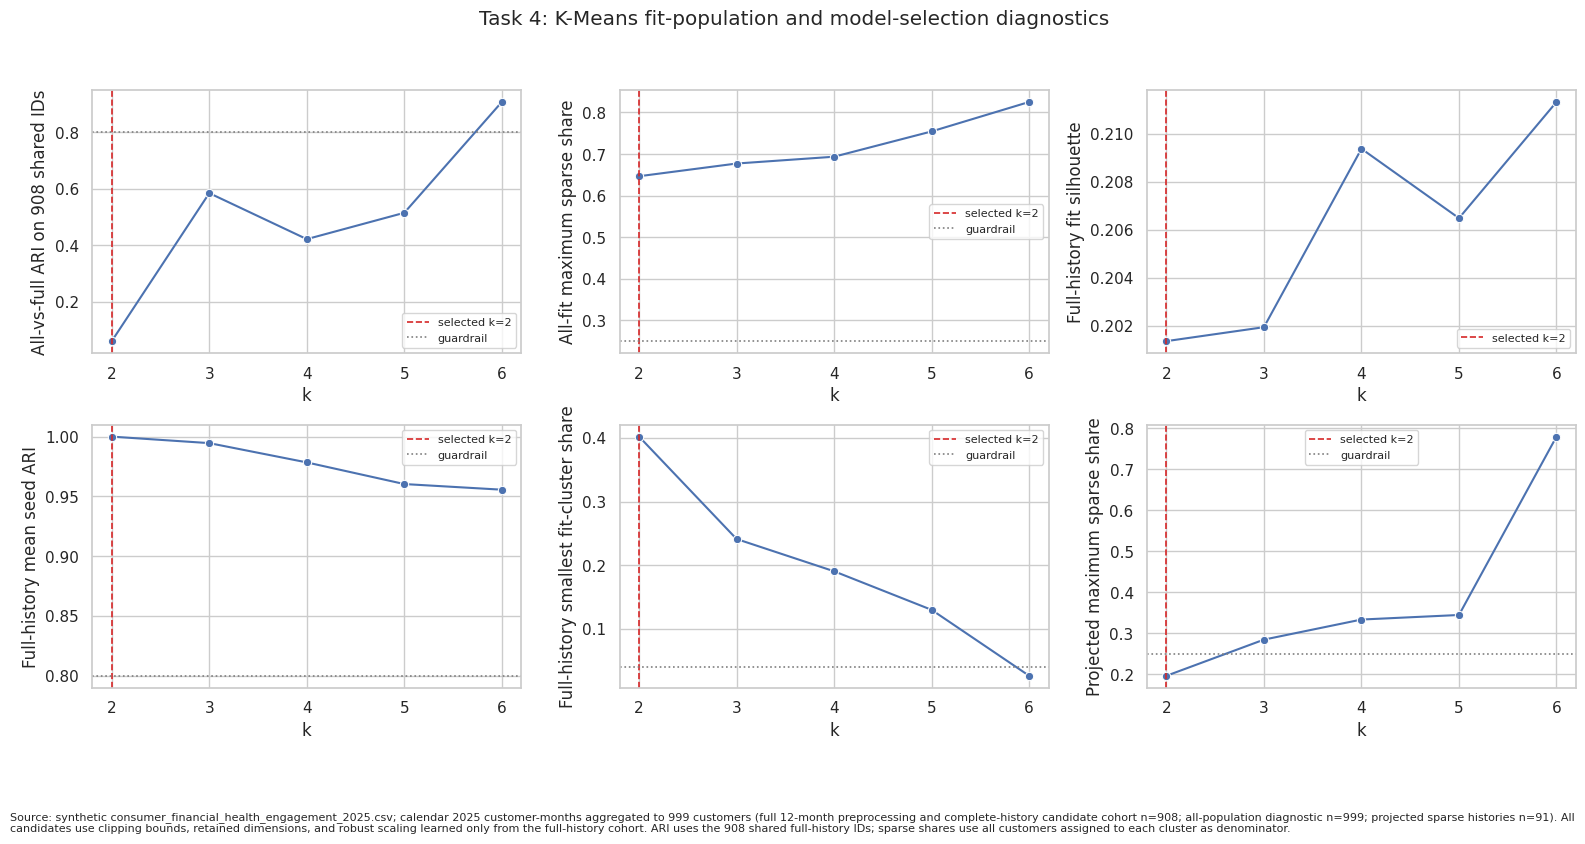

In [7]:
figure, axes = plt.subplots(2, 3, figsize=(16, 8.5))
diagnostic_specs = [
    ('all_vs_full_shared_ari', 'All-vs-full ARI on 908 shared IDs', MINIMUM_SHARED_FIT_ARI),
    (
        'all_population_max_sparse_share',
        'All-fit maximum sparse share',
        MAXIMUM_SPARSE_HISTORY_SHARE,
    ),
    ('full_history_silhouette', 'Full-history fit silhouette', None),
    ('full_history_mean_seed_ari', 'Full-history mean seed ARI', MINIMUM_SEED_ARI),
    (
        'full_history_minimum_cluster_share',
        'Full-history smallest fit-cluster share',
        MINIMUM_CLUSTER_SHARE,
    ),
    (
        'projected_max_sparse_share',
        'Projected maximum sparse share',
        MAXIMUM_SPARSE_HISTORY_SHARE,
    ),
]
for axis, (metric_name, axis_label, guardrail) in zip(axes.flat, diagnostic_specs):
    sns.lineplot(data=model_diagnostics, x='k', y=metric_name, marker='o', ax=axis)
    axis.axvline(
        selected_k, color='tab:red', linestyle='--', linewidth=1.2,
        label=f'selected k={selected_k}',
    )
    if guardrail is not None:
        axis.axhline(
            guardrail, color='tab:gray', linestyle=':', linewidth=1.2,
            label='guardrail',
        )
    axis.set_ylabel(axis_label)
    axis.set_xticks(range(2, 7))
    axis.legend(fontsize=8)
figure.suptitle('Task 4: K-Means fit-population and model-selection diagnostics', y=0.98)
figure.text(
    0.01,
    0.01,
    'Source: synthetic consumer_financial_health_engagement_2025.csv; calendar 2025 '
    f'customer-months aggregated to 999 customers (full 12-month preprocessing and '
    f'complete-history candidate cohort n={full_history_count:,}; all-population diagnostic '
    f'n={len(customer_features):,}; projected sparse histories n={sparse_history_count:,}). '
    'All candidates use clipping bounds, retained dimensions, and robust scaling learned '
    'only from the full-history cohort. ARI uses the 908 shared full-history IDs; sparse '
    'shares use all customers assigned to each cluster as denominator.',
    ha='left',
    va='bottom',
    fontsize=8,
    wrap=True,
)
figure.tight_layout(rect=[0, 0.10, 1, 0.95])
figure.savefig(CHART_DIRECTORY / 'task4_k_diagnostics.png', dpi=160, bbox_inches='tight')
plt.show()
plt.close(figure)

**Interpretation.** The red line identifies the selected `k`, but no diagnostic proves that the synthetic population contains natural groups. Silhouette measures geometric separation, seed ARI measures repeatability, fit-set minimum share exposes tiny fitted clusters, and the history diagnostics test whether incomplete histories determine the geometry. The decision tables visibly retain rejected all-population candidates and the reason for each rejection.

## 6. Fit the selected model and assign supported labels

The selected estimator remains genuine K-Means. If the all-population path is ineligible, the final estimator is fitted only on the 908 complete-history rows after the frozen full-history preprocessing, then its `.predict` method assigns all 999 customers exactly once. Labels are generated only after fitting. Each name reflects the centroid dimension with the largest absolute robust-scaled departure from the full-history preprocessing median and includes the segment number to stay unique. An online-spend label describes median online-spend share only; it does not measure digital or non-POS adoption, because digital payments such as QR can occur without the online flag. These are behavioral archetypes, not official health or engagement bands.

In [8]:
if selected_fit_path == 'all_population':
    selected_fit_features = all_customer_projected_features
    selected_fit_customer_count = len(customer_features)
    selected_fit_population_label = 'all customer profiles'
else:
    selected_fit_features = full_history_fit_features
    selected_fit_customer_count = full_history_count
    selected_fit_population_label = 'complete 12-month customer profiles'

selected_model = KMeans(
    n_clusters=selected_k, random_state=RANDOM_STATE, n_init=KMEANS_N_INIT
).fit(selected_fit_features)
customer_features['cluster'] = selected_model.predict(
    all_customer_projected_features
).astype(int)

feature_label_phrases = {
    'median_spend_to_income_ratio': ('Lower spend-to-income', 'Higher spend-to-income'),
    'median_credit_utilization_ratio': ('Lower credit utilization', 'Higher credit utilization'),
    'median_essential_spend_ratio': ('Less essential-focused', 'More essential-focused'),
    'median_online_spend_ratio': ('Lower online-spend share', 'Higher online-spend share'),
    'log1p_mean_monthly_transaction_count': ('Lower-frequency activity', 'Higher-frequency activity'),
}
cluster_label_by_id = {}
for cluster_id, centroid in enumerate(selected_model.cluster_centers_):
    dominant_position = int(np.argmax(np.abs(centroid)))
    dominant_feature = model_features[dominant_position]
    direction_index = int(centroid[dominant_position] >= 0)
    phrase = feature_label_phrases[dominant_feature][direction_index]
    cluster_label_by_id[cluster_id] = f'{phrase} — Segment {cluster_id + 1}'
customer_features['cluster_label'] = customer_features['cluster'].map(cluster_label_by_id)

assignments = customer_features[['consumer_id', 'cluster', 'cluster_label']].copy()
if len(assignments) != 999 or not assignments['consumer_id'].is_unique:
    raise ValueError('Selected model did not assign exactly one segment to each of 999 consumers.')
if assignments[['cluster', 'cluster_label']].isna().any().any():
    raise ValueError('At least one customer assignment is incomplete.')
display(assignments['cluster_label'].value_counts().rename('customers').to_frame())

,customers
cluster_label,
Lower-frequency activity — Segment 1,545
Higher online-spend share — Segment 2,454


In [9]:
if selected_fit_path == 'all_population':
    selected_silhouette = float(selected_diagnostic['all_population_silhouette'])
    selected_stability = float(selected_diagnostic['all_population_mean_seed_ari'])
    selected_minimum_share = float(
        selected_diagnostic['all_population_minimum_cluster_share']
    )
    selected_max_sparse_share = float(
        selected_diagnostic['all_population_max_sparse_share']
    )
    selected_sparse_composition = selected_diagnostic[
        'all_population_sparse_composition'
    ]
else:
    selected_silhouette = float(selected_diagnostic['full_history_silhouette'])
    selected_stability = float(selected_diagnostic['full_history_mean_seed_ari'])
    selected_minimum_share = float(
        selected_diagnostic['full_history_minimum_cluster_share']
    )
    selected_max_sparse_share = float(selected_diagnostic['projected_max_sparse_share'])
    selected_sparse_composition = selected_diagnostic['projected_sparse_composition']

selected_shared_fit_ari = float(selected_diagnostic['all_vs_full_shared_ari'])
if selected_silhouette >= 0.50:
    separation_statement = 'strong geometric separation'
elif selected_silhouette >= 0.25:
    separation_statement = 'moderate geometric separation'
else:
    separation_statement = 'weak geometric separation; use the segments cautiously'
if selected_stability >= 0.90:
    stability_statement = 'high repeatability across tested seeds'
elif selected_stability >= 0.80:
    stability_statement = 'acceptable repeatability across tested seeds'
else:
    stability_statement = 'seed sensitivity below the predeclared stability guardrail'
print(
    f'Chosen k={selected_k}; fit population={selected_fit_population_label} '
    f'(n={selected_fit_customer_count:,}); silhouette={selected_silhouette:.3f} '
    f'({separation_statement}); mean seed ARI={selected_stability:.3f} '
    f'({stability_statement}); smallest fit cluster={selected_minimum_share:.1%}; '
    f'maximum sparse-history share after all-customer assignment='
    f'{selected_max_sparse_share:.1%}.'
)
print(
    f'All-population-vs-full-history ARI on 908 shared IDs at k={selected_k}: '
    f'{selected_shared_fit_ari:.3f}. Selection basis: {selection_basis}.'
)
print(
    f'All 999 customers assigned with selected_model.predict(); '
    f'sparse-history assignments (n={sparse_history_count:,}): '
    f'{selected_sparse_composition}.'
)

Chosen k=2; fit population=complete 12-month customer profiles (n=908); silhouette=0.201 (weak geometric separation; use the segments cautiously); mean seed ARI=1.000 (high repeatability across tested seeds); smallest fit cluster=40.2%; maximum sparse-history share after all-customer assignment=19.6%.
All-population-vs-full-history ARI on 908 shared IDs at k=2: 0.061. Selection basis: all-population candidates failed population-sensitivity guardrails; selected an eligible complete-history fit and projected all customers.
All 999 customers assigned with selected_model.predict(); sparse-history assignments (n=91): 0: 2/545 (0.4%); 1: 89/454 (19.6%).


## 7. Sparse-history assignment and December sensitivity

The candidate diagnostics above compare the all-customer and complete-history K-Means fits on the same 908 IDs after identical full-history-trained preprocessing. The selected assignment table below makes the projected sparse-history membership visible. For the December-observed subset, December ratios are clipped with the frozen full-history bounds, transformed by the frozen full-history scaler, and mapped with the selected fitted estimator; this is a timing-sensitivity diagnostic, not a new model or a statement that anyone is currently contactable.

In [10]:
sparse_membership = pd.crosstab(
    customer_features['cluster_label'], customer_features['has_sparse_history'], margins=True
).rename(columns={False: 'full_12_months', True: 'sparse_under_12_months'})

december_rows = monthly_data.loc[
    monthly_data['analysis_month'].eq(pd.Timestamp('2025-12-01'))
].copy()
december_snapshot = december_rows[[
    'consumer_id', 'spend_to_income_ratio', 'credit_utilization_ratio',
    'essential_spend_ratio', 'online_spend_ratio', 'transaction_count',
]].rename(columns={
    'spend_to_income_ratio': 'median_spend_to_income_ratio',
    'credit_utilization_ratio': 'median_credit_utilization_ratio',
    'essential_spend_ratio': 'median_essential_spend_ratio',
    'online_spend_ratio': 'median_online_spend_ratio',
})
december_snapshot['log1p_mean_monthly_transaction_count'] = np.log1p(
    december_snapshot.pop('transaction_count')
)
for clip_record in clip_rows:
    december_snapshot[clip_record['feature']] = december_snapshot[clip_record['feature']].clip(
        clip_record['lower_1pct_full_history'],
        clip_record['upper_99pct_full_history'],
    )
december_scaled = full_history_scaler.transform(december_snapshot[model_features])
december_snapshot['december_cluster'] = selected_model.predict(december_scaled).astype(int)
december_comparison = december_snapshot.merge(
    assignments[['consumer_id', 'cluster']], on='consumer_id', how='left', validate='one_to_one'
)
december_membership_ari = adjusted_rand_score(
    december_comparison['cluster'], december_comparison['december_cluster']
)
december_same_cluster_rate = december_comparison['cluster'].eq(
    december_comparison['december_cluster']
).mean()

display(sparse_membership)
print(
    f'Selected fit population: {selected_fit_population_label} '
    f'(n={selected_fit_customer_count:,}); held-out sparse histories predicted='
    f'{sparse_history_count if selected_fit_path == "full_history" else 0:,}; '
    f'total assigned={len(assignments):,}.'
)
print(
    f'December-observed customers: {len(december_comparison):,}; '
    f'annual-vs-December assignment ARI: {december_membership_ari:.3f}; '
    f'same-centroid-label rate: {december_same_cluster_rate:.1%}.'
)

has_sparse_history,full_12_months,sparse_under_12_months,All
cluster_label,,,
Higher online-spend share — Segment 2,365,89,454
Lower-frequency activity — Segment 1,543,2,545
All,908,91,999


Selected fit population: complete 12-month customer profiles (n=908); held-out sparse histories predicted=91; total assigned=999.
December-observed customers: 918; annual-vs-December assignment ARI: 0.049; same-centroid-label rate: 61.9%.


**Interpretation.** Low agreement between the all-population and complete-history fits is a rejection signal, not wording to append after selecting the confounded solution. When the complete-history path is selected, sparse customers influence neither preprocessing nor fitted centroids, but remain in the deliverable through genuine K-Means prediction. The December comparison only asks whether a single recent month resembles each customer's annual archetype; it must not be interpreted as churn, permanence, or current eligibility for contact.

## 8. Cluster profiles and post-hoc score diagnostics

Profiles report customer-level denominators unless explicitly labeled as months. `Ever stressed` means at least one **observed** month with health score <40; it does not treat missing months as healthy. The two descriptive crossover rules are health <40 with engagement ≥80, and health ≥80 with engagement <40. Scores and crossovers never enter K-Means.

In [11]:
december_observed_ids = set(december_comparison['consumer_id'])
december_same_cluster_ids = set(
    december_comparison.loc[
        december_comparison['cluster'].eq(december_comparison['december_cluster']), 'consumer_id'
    ]
)
customer_features['observed_in_december'] = customer_features['consumer_id'].isin(december_observed_ids)
customer_features['december_matches_annual_cluster'] = customer_features['consumer_id'].isin(
    december_same_cluster_ids
)
customer_features['ever_health_under_40'] = customer_features['months_health_under_40'].gt(0)
customer_features['ever_stressed_high_engagement'] = customer_features[
    'months_stressed_high_engagement'
].gt(0)
customer_features['ever_healthy_low_engagement'] = customer_features[
    'months_healthy_low_engagement'
].gt(0)

def most_common_with_sample(values):
    counts = values.value_counts(dropna=False)
    return f'{counts.index[0]} (n={int(counts.iloc[0])})'

profile_group = customer_features.groupby(['cluster', 'cluster_label'], observed=True)
behavior_profile = profile_group.agg(
    customers=('consumer_id', 'size'),
    spend_to_income_median=('median_spend_to_income_ratio', 'median'),
    credit_utilization_median=('median_credit_utilization_ratio', 'median'),
    essential_share_median=('median_essential_spend_ratio', 'median'),
    online_share_median=('median_online_spend_ratio', 'median'),
    log_frequency_median=('log1p_mean_monthly_transaction_count', 'median'),
    mean_health_score=('mean_financial_health_score', 'mean'),
    mean_engagement_score=('mean_engagement_score', 'mean'),
    latest_health_score=('latest_financial_health_score', 'mean'),
    latest_engagement_score=('latest_engagement_score', 'mean'),
    ever_stressed_rate=('ever_health_under_40', 'mean'),
    stressed_high_engagement_rate=('ever_stressed_high_engagement', 'mean'),
    healthy_low_engagement_rate=('ever_healthy_low_engagement', 'mean'),
    observed_months_mean=('n_observed_months', 'mean'),
    sparse_history_rate=('has_sparse_history', 'mean'),
    december_observed_count=('observed_in_december', 'sum'),
).reset_index()
behavior_profile['population_share'] = behavior_profile['customers'] / len(customer_features)

demographic_profile = profile_group.agg(
    customers=('consumer_id', 'size'),
    latest_age_mean=('latest_age', 'mean'),
    latest_age_min=('latest_age', 'min'),
    latest_age_max=('latest_age', 'max'),
    most_common_gender=('latest_gender', most_common_with_sample),
    most_common_occupation=('latest_occupation', most_common_with_sample),
    most_common_province=('latest_province_city', most_common_with_sample),
).reset_index()

rate_columns = [column for column in behavior_profile if column.endswith('_rate') or column.endswith('_share')]
behavior_display = behavior_profile.copy()
behavior_display[rate_columns] = behavior_display[rate_columns].mul(100)
display(behavior_display.round(2))
display(demographic_profile.round(1))

,cluster,cluster_label,customers,spend_to_income_median,credit_utilization_median,essential_share_median,online_share_median,log_frequency_median,mean_health_score,mean_engagement_score,latest_health_score,latest_engagement_score,ever_stressed_rate,stressed_high_engagement_rate,healthy_low_engagement_rate,observed_months_mean,sparse_history_rate,december_observed_count,population_share
0,0,Lower-frequency activity — Segment 1,545,0.620,0.160,0.530,0.170,4.810,67.070,76.500,54.720,78.400,8.810,5.320,0.000,11.960,0.370,544,54.550
1,1,Higher online-spend share — Segment 2,454,0.670,0.180,0.430,0.230,5.210,65.380,74.090,55.830,74.620,4.850,3.520,0.220,9.850,19.600,374,45.450


,cluster,cluster_label,customers,latest_age_mean,latest_age_min,latest_age_max,most_common_gender,most_common_occupation,most_common_province
0,0,Lower-frequency activity — Segment 1,545,56.600,20,96,Nữ (n=284),Nhà khoa học thính học (n=9),Thành phố Hồ Chí Minh (n=74)
1,1,Higher online-spend share — Segment 2,454,42.200,15,95,Nam (n=233),Chuyên viên dựng phim (n=5),Thành phố Hồ Chí Minh (n=61)


Heatmap k=2 scaling check passed: 0 of 8 columns display ±1.00 in both segments.


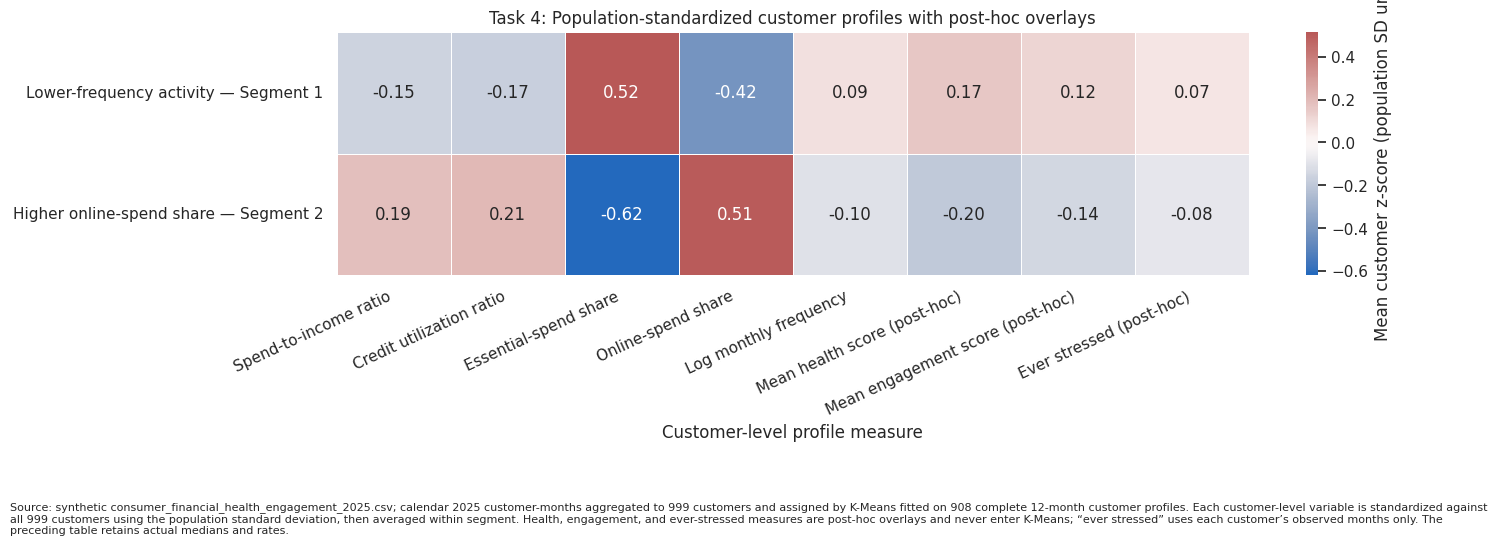

In [12]:
profile_variable_labels = {
    'Spend-to-income ratio': 'median_spend_to_income_ratio',
    'Credit utilization ratio': 'median_credit_utilization_ratio',
    'Essential-spend share': 'median_essential_spend_ratio',
    'Online-spend share': 'median_online_spend_ratio',
    'Log monthly frequency': 'log1p_mean_monthly_transaction_count',
    'Mean health score (post-hoc)': 'mean_financial_health_score',
    'Mean engagement score (post-hoc)': 'mean_engagement_score',
    'Ever stressed (post-hoc)': 'ever_health_under_40',
}
customer_profile_values = customer_features[
    list(profile_variable_labels.values())
].rename(columns={
    source_column: display_label
    for display_label, source_column in profile_variable_labels.items()
})
profile_population_standard_deviation = customer_profile_values.std(ddof=0)
constant_profile_variables = profile_population_standard_deviation[
    profile_population_standard_deviation.eq(0)
].index.tolist()
if constant_profile_variables:
    raise ValueError(
        f'Cannot population-standardize constant profile variables: {constant_profile_variables}'
    )
standardized_customer_profiles = (
    customer_profile_values - customer_profile_values.mean()
) / profile_population_standard_deviation
standardized_customer_profiles['cluster_label'] = customer_features[
    'cluster_label'
].to_numpy()
segment_profile_order = behavior_profile['cluster_label'].tolist()
standardized_profile = (
    standardized_customer_profiles.groupby('cluster_label', observed=True)
    .mean()
    .reindex(segment_profile_order)
)

displayed_pm_one_columns = standardized_profile.abs().round(2).eq(1.0).all(axis=0)
if selected_k == 2 and displayed_pm_one_columns.any():
    raise ValueError(
        'Customer-population standardization still produced a k=2 column displayed as '
        f'±1.00 in both segments: {displayed_pm_one_columns[displayed_pm_one_columns].index.tolist()}'
    )
if selected_k == 2:
    print(
        'Heatmap k=2 scaling check passed: 0 of '
        f'{standardized_profile.shape[1]} columns display ±1.00 in both segments.'
    )

figure, axis = plt.subplots(figsize=(15, max(5.5, selected_k * 0.9)))
sns.heatmap(
    standardized_profile,
    cmap='vlag',
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={
        'label': 'Mean customer z-score (population SD units)'
    },
    ax=axis,
)
axis.set_title(
    'Task 4: Population-standardized customer profiles with post-hoc overlays'
)
axis.set_xlabel('Customer-level profile measure')
axis.set_ylabel('')
axis.tick_params(axis='x', labelrotation=25)
for label in axis.get_xticklabels():
    label.set_horizontalalignment('right')
figure.text(
    0.01,
    0.01,
    'Source: synthetic consumer_financial_health_engagement_2025.csv; calendar 2025 '
    f'customer-months aggregated to 999 customers and assigned by K-Means fitted on '
    f'{selected_fit_customer_count:,} {selected_fit_population_label}. Each customer-level '
    'variable is standardized against all 999 customers using the population standard '
    'deviation, then averaged within segment. Health, engagement, and ever-stressed '
    'measures are post-hoc overlays and never enter K-Means; “ever stressed” uses each '
    'customer’s observed months only. The preceding table retains actual medians and rates.',
    ha='left',
    va='bottom',
    fontsize=8,
    wrap=True,
)
figure.tight_layout(rect=[0, 0.15, 1, 1])
figure.savefig(CHART_DIRECTORY / 'task4_cluster_behavior_profile.png', dpi=160, bbox_inches='tight')
plt.show()
plt.close(figure)

**Interpretation.** Red and blue cells show segment means above or below the all-999-customer population mean in customer-population standard-deviation units; they are not standardized against the two segment summaries. Because standardization occurs at customer level before aggregation, a two-segment solution is not mechanically forced to ±1.00. The preceding tables retain actual medians, rates, and customer denominators. Health, engagement, and stress measures are post-hoc overlays used to understand outcomes the behavioral model may miss; they never enter K-Means or the segment names.

In [13]:
customer_features['age_band'] = pd.cut(
    customer_features['latest_age'],
    bins=[17, 25, 35, 45, 55, np.inf],
    labels=['18–25', '26–35', '36–45', '46–55', '56+'],
    right=True,
)
gender_cluster_share = pd.crosstab(
    customer_features['latest_gender'], customer_features['cluster_label'], normalize='index'
)
largest_provinces = customer_features['latest_province_city'].value_counts().head(8).index
province_cluster_share = pd.crosstab(
    customer_features.loc[customer_features['latest_province_city'].isin(largest_provinces), 'latest_province_city'],
    customer_features.loc[customer_features['latest_province_city'].isin(largest_provinces), 'cluster_label'],
    normalize='index',
)
age_cluster_counts = pd.crosstab(customer_features['age_band'], customer_features['cluster_label'])
display((gender_cluster_share * 100).round(1).rename_axis('latest_gender'))
display(age_cluster_counts.rename_axis('latest_age_band'))

cluster_label,Higher online-spend share — Segment 2,Lower-frequency activity — Segment 1
latest_gender,,
Nam,47.200,52.800
Nữ,43.800,56.200


cluster_label,Higher online-spend share — Segment 2,Lower-frequency activity — Segment 1
latest_age_band,,
18–25,66,11
26–35,114,69
36–45,103,58
46–55,80,116
56+,84,291


/tmp/ipykernel_486674/425134317.py:136: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  figure.tight_layout(rect=[0, 0.16, 1, 0.92], w_pad=2.0, h_pad=2.4)


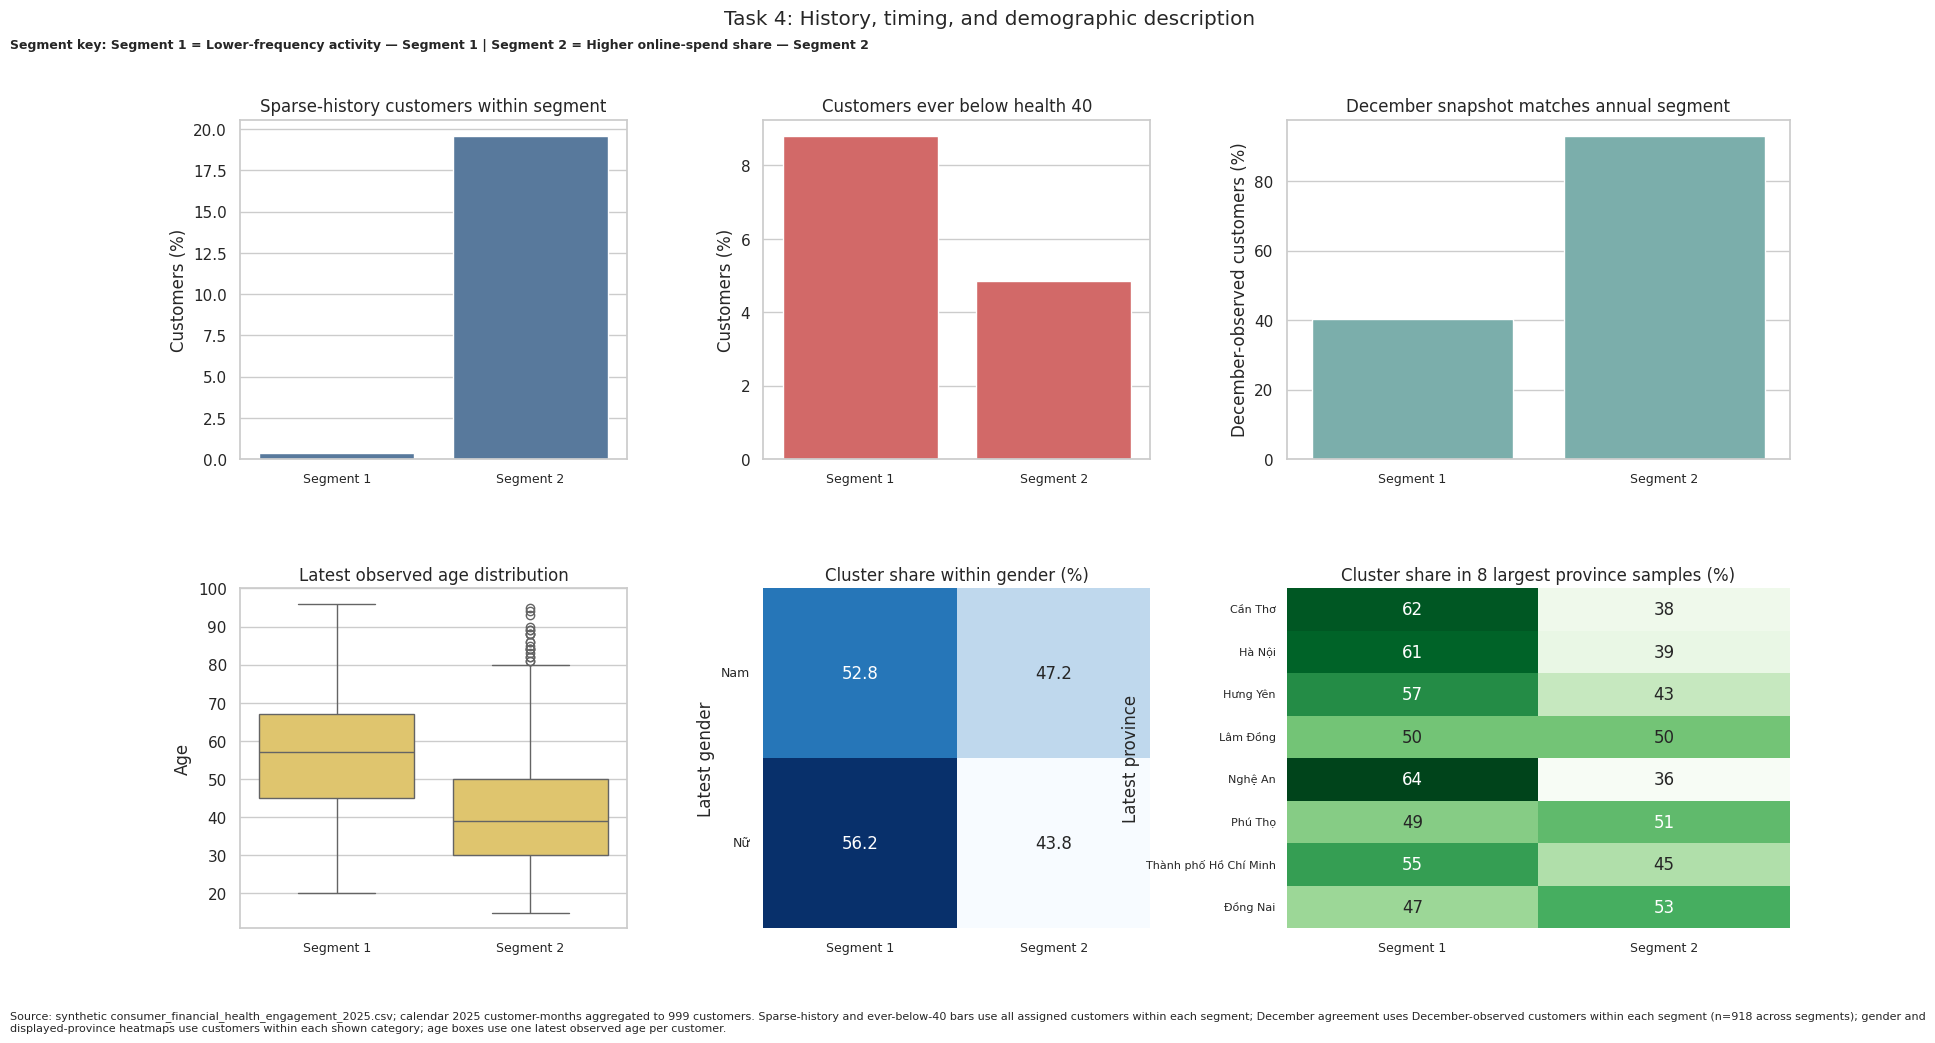

In [14]:
segment_ids = sorted(cluster_label_by_id)
segment_short_label_by_id = {
    cluster_id: f'Segment {cluster_id + 1}' for cluster_id in segment_ids
}
segment_short_order = [
    segment_short_label_by_id[cluster_id] for cluster_id in segment_ids
]
segment_label_key = ' | '.join(
    f'{segment_short_label_by_id[cluster_id]} = {cluster_label_by_id[cluster_id]}'
    for cluster_id in segment_ids
)
cluster_label_to_short = {
    cluster_label_by_id[cluster_id]: segment_short_label_by_id[cluster_id]
    for cluster_id in segment_ids
}
plot_customer_features = customer_features.assign(
    segment_short_label=customer_features['cluster'].map(segment_short_label_by_id)
)
history_chart = behavior_profile.set_index('cluster').reindex(segment_ids)
history_chart.index = segment_short_order
december_agreement_by_cluster = (
    customer_features.loc[customer_features['observed_in_december']]
    .groupby('cluster', observed=True)['december_matches_annual_cluster']
    .mean()
    .reindex(segment_ids)
)
december_agreement_by_cluster.index = segment_short_order
gender_cluster_share_plot = (
    gender_cluster_share.rename(columns=cluster_label_to_short)
    .reindex(columns=segment_short_order)
)
province_cluster_share_plot = (
    province_cluster_share.rename(columns=cluster_label_to_short)
    .reindex(columns=segment_short_order)
)

figure, axes = plt.subplots(
    2,
    3,
    figsize=(20, 10.5),
    gridspec_kw={
        'width_ratios': [1.0, 1.0, 1.3],
        'hspace': 0.38,
        'wspace': 0.32,
    },
)
sns.barplot(
    x=history_chart.index,
    y=history_chart['sparse_history_rate'] * 100,
    ax=axes[0, 0],
    color='#4C78A8',
)
axes[0, 0].set_title('Sparse-history customers within segment')
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('Customers (%)')
sns.barplot(
    x=history_chart.index,
    y=history_chart['ever_stressed_rate'] * 100,
    ax=axes[0, 1],
    color='#E45756',
)
axes[0, 1].set_title('Customers ever below health 40')
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('Customers (%)')
sns.barplot(
    x=december_agreement_by_cluster.index,
    y=december_agreement_by_cluster.values * 100,
    ax=axes[0, 2],
    color='#72B7B2',
)
axes[0, 2].set_title('December snapshot matches annual segment')
axes[0, 2].set_ylabel('December-observed customers (%)')
axes[0, 2].set_xlabel('')
sns.boxplot(
    data=plot_customer_features,
    x='segment_short_label',
    y='latest_age',
    order=segment_short_order,
    ax=axes[1, 0],
    color='#F2CF5B',
)
axes[1, 0].set_title('Latest observed age distribution')
axes[1, 0].set_xlabel('')
axes[1, 0].set_ylabel('Age')
sns.heatmap(
    gender_cluster_share_plot * 100,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    cbar=False,
    ax=axes[1, 1],
)
axes[1, 1].set_title('Cluster share within gender (%)')
axes[1, 1].set_xlabel('')
axes[1, 1].set_ylabel('Latest gender')
sns.heatmap(
    province_cluster_share_plot * 100,
    annot=True,
    fmt='.0f',
    cmap='Greens',
    cbar=False,
    ax=axes[1, 2],
)
axes[1, 2].set_title('Cluster share in 8 largest province samples (%)')
axes[1, 2].set_xlabel('')
axes[1, 2].set_ylabel('Latest province')
for axis in axes.flat:
    axis.tick_params(axis='x', labelrotation=0, labelsize=9)
axes[1, 1].tick_params(axis='y', labelrotation=0, labelsize=9)
axes[1, 2].tick_params(axis='y', labelrotation=0, labelsize=8, pad=2)
figure.suptitle('Task 4: History, timing, and demographic description', y=0.985)
figure.text(
    0.01,
    0.945,
    f'Segment key: {segment_label_key}',
    ha='left',
    va='bottom',
    fontsize=9,
    fontweight='bold',
    wrap=True,
)
figure.text(
    0.01,
    0.01,
    'Source: synthetic consumer_financial_health_engagement_2025.csv; calendar 2025 '
    f'customer-months aggregated to 999 customers. Sparse-history and ever-below-40 '
    'bars use all assigned customers within each segment; December agreement uses '
    f'December-observed customers within each segment (n={len(december_comparison):,} '
    'across segments); gender and displayed-province heatmaps use customers within each '
    'shown category; age boxes use one latest observed age per customer.',
    ha='left',
    va='bottom',
    fontsize=8,
    wrap=True,
)
figure.tight_layout(rect=[0, 0.16, 1, 0.92], w_pad=2.0, h_pad=2.4)
figure.savefig(CHART_DIRECTORY / 'task4_history_fairness_diagnostics.png', dpi=160, bbox_inches='tight')
plt.show()
plt.close(figure)

**Interpretation.** A segment dominated by short histories or with low December agreement may be a coverage/timing artifact rather than a durable archetype. Age, gender, occupation, and province were not model inputs. These panels are descriptive sample checks only: synthetic category patterns do not establish bias, need, causality, or real-population group differences, and small category samples should not drive customer treatment.

## 9. Export the Task 4 contracts

`segmentation_features.csv` contains the un-clipped engineered candidate behavioral features plus observed-history and latest-state diagnostics, preserving the established schema and feature semantics. Clipping is isolated to the model matrix. `customer_segments.csv` contains only the unique assignment contract. Dates are ISO strings. The exports contain no raw VND values, prediction target, score-derived band, or model object.

In [15]:
feature_export_columns = [
    'consumer_id',
    'median_spend_to_income_ratio',
    'median_credit_utilization_ratio',
    'median_essential_spend_ratio',
    'median_online_spend_ratio',
    'log1p_mean_monthly_transaction_count',
    'n_observed_months',
    'latest_observed_month',
    'months_health_under_40',
    'stress_month_share',
    'months_stressed_high_engagement',
    'months_healthy_low_engagement',
    'mean_financial_health_score',
    'mean_engagement_score',
    'latest_financial_health_score',
    'latest_engagement_score',
    'latest_age',
    'latest_gender',
    'latest_occupation',
    'latest_province_city',
]
feature_export = customer_features[feature_export_columns].copy()
feature_export['latest_observed_month'] = feature_export['latest_observed_month'].dt.strftime('%Y-%m-%d')
assignment_export = assignments.sort_values('consumer_id').reset_index(drop=True)
feature_export = feature_export.sort_values('consumer_id').reset_index(drop=True)

if len(feature_export) != 999 or not feature_export['consumer_id'].is_unique:
    raise ValueError('Feature export must contain exactly 999 unique consumer IDs.')
if set(feature_export['consumer_id']) != source_consumer_ids:
    raise ValueError('Feature export IDs do not exactly match the source population.')
if set(assignment_export['consumer_id']) != source_consumer_ids:
    raise ValueError('Assignment export IDs do not exactly match the source population.')
joined_contract = feature_export[['consumer_id']].merge(
    assignment_export, on='consumer_id', how='inner', validate='one_to_one'
)
if len(joined_contract) != 999:
    raise ValueError('Feature and assignment exports do not form a complete 1:1 join.')
if feature_export.isna().any().any() or assignment_export.isna().any().any():
    raise ValueError('Task 4 exports contain unexpected missing values.')

feature_output_path = OUTPUT_DIRECTORY / 'segmentation_features.csv'
assignment_output_path = OUTPUT_DIRECTORY / 'customer_segments.csv'
try:
    feature_export.to_csv(feature_output_path, index=False)
    assignment_export.to_csv(assignment_output_path, index=False)
except OSError as error:
    raise RuntimeError(f'Could not write Task 4 CSV outputs to {OUTPUT_DIRECTORY}') from error
print(f'Wrote {len(feature_export):,} feature rows to {feature_output_path}')
print(f'Wrote {len(assignment_export):,} assignments to {assignment_output_path}')

Wrote 999 feature rows to /home/pearspringmind/Studying/BI-UEL/code/outputs/segmentation_features.csv
Wrote 999 assignments to /home/pearspringmind/Studying/BI-UEL/code/outputs/customer_segments.csv


## 10. Limitations, responsible use, and future work

- **Model evidence:** the chosen fit-set silhouette, seed ARI, minimum fit-cluster share, all-vs-full shared-ID ARI, projected sparse-history concentration, and December sensitivity determine whether the solution is usable only as weak, moderate, or strong exploratory evidence. A fitted model is not proof of natural customer types.
- **Sparse and unequal histories:** 91 customers have fewer than 12 observed months. Full-history winsorization bounds, redundancy screening, scaling, and—when selected—K-Means fitting exclude these profiles; the fitted estimator still predicts them so the exports retain 100% coverage. No missing month is silently imputed, and projected assignments carry greater uncertainty.
- **Synthetic and dense activity:** all identities, demographics, geography, income, credit, balances, and transactions are synthetic. Transaction volumes are unusually high, which is why raw VND and untransformed volumes are excluded. Results require validation on real, consented operational data.
- **Time:** annual summaries can hide month-level stress. Historical stress counts and latest scores remain beside the label. December-observed membership is not current contactability, retention, churn, or proof of a persistent state.
- **Demographics and interpretation:** demographic fields are post-hoc only. Displayed patterns are descriptive and may reflect the generator or unequal samples; they must not justify adverse treatment. Financial health is a wellbeing indicator, never a credit-decision score.
- **Geometry:** K-Means favors roughly spherical Euclidean groups. Future work should collect longer histories, monitor centroid and assignment drift, validate segment usefulness with customer outcomes, and compare robust alternatives such as GMM or hierarchical clustering without forcing official score bands into the fit.

**Business use:** treat labels as supportive planning archetypes and combine them with explicit observed evidence before offering budgeting, education, reminder, or online-purchase support. Online-spend share is not a proxy for digital or non-POS adoption. Never use segments to deny credit, reduce a limit, block an account, or claim causal need.